# GetAround — Analyse des retards (Delay Analysis)

Objectif : aider le Product Manager à choisir le **seuil** et le **périmètre** (toutes les voitures ou Connect uniquement) d'un délai minimum obligatoire entre deux locations, pour réduire les retards de checkin subis par les conducteurs suivants.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Chargement et exploration des données

In [2]:
data = pd.read_excel("get_around_delay_analysis.xlsx")
print("Nombre de locations :", data.shape[0])
data.head()


Nombre de locations : 21310


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [3]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  str    
 3   state                                       21310 non-null  str    
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.4 MB


In [4]:
print(data["state"].value_counts())
print()
print(data["checkin_type"].value_counts())


state
ended       18045
canceled     3265
Name: count, dtype: int64

checkin_type
mobile     17003
connect     4307
Name: count, dtype: int64


In [5]:
print("Valeurs manquantes :")
print(data.isnull().sum())


Valeurs manquantes :
rental_id                                         0
car_id                                            0
checkin_type                                      0
state                                             0
delay_at_checkout_in_minutes                   4964
previous_ended_rental_id                      19469
time_delta_with_previous_rental_in_minutes    19469
dtype: int64


**Observations initiales :**
- 21 310 locations au total, dont 3 265 annulées (`canceled`) et 18 045 terminées (`ended`)
- Deux types de checkin : `mobile` (majoritaire) et `connect`
- Beaucoup de valeurs manquantes sur `delay_at_checkout_in_minutes` (le retard n'est mesuré que pour les locations terminées) et sur les colonnes liées à la location précédente (seules les locations "enchaînées" à une précédente ont ces informations)

## 2. Distribution des retards au checkout

In [6]:
delay_clean = data["delay_at_checkout_in_minutes"].dropna()
print(delay_clean.describe())
print()
print("Part des locations rendues en retard (>0 min) :", (delay_clean > 0).mean().round(3))
print("Part des locations rendues en avance (<0 min) :", (delay_clean < 0).mean().round(3))


count    16346.000000
mean        59.701517
std       1002.561635
min     -22433.000000
25%        -36.000000
50%          9.000000
75%         67.000000
max      71084.000000
Name: delay_at_checkout_in_minutes, dtype: float64

Part des locations rendues en retard (>0 min) : 0.575
Part des locations rendues en avance (<0 min) : 0.417


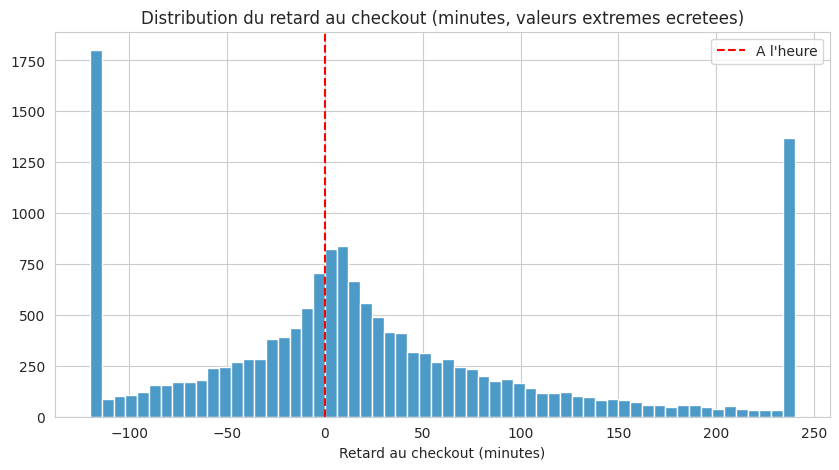

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
delay_clipped = delay_clean.clip(-120, 240)  # on ecrete les valeurs extremes pour la lisibilite
ax.hist(delay_clipped, bins=60, color="#4B9AC7")
ax.axvline(0, color="red", linestyle="--", label="A l'heure")
ax.set_title("Distribution du retard au checkout (minutes, valeurs extremes ecretees)")
ax.set_xlabel("Retard au checkout (minutes)")
ax.legend()
plt.show()


**Observation :** environ la moitié des locations sont rendues avec un léger retard. La distribution est centrée proche de 0 mais avec une traîne longue vers les retards importants — ce sont ces cas extrêmes qui posent problème pour le conducteur suivant.

## 3. Les locations "enchaînées" : la vraie zone à risque

In [8]:
chained = data[data["previous_ended_rental_id"].notnull()].copy()
print(f"Locations enchainees a une location precedente : {len(chained)} ({len(chained)/len(data)*100:.1f}% du total)")
print()
print(chained["time_delta_with_previous_rental_in_minutes"].describe())


Locations enchainees a une location precedente : 1841 (8.6% du total)



count    1841.000000
mean      279.288430
std       254.594486
min         0.000000
25%        60.000000
50%       180.000000
75%       540.000000
max       720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64


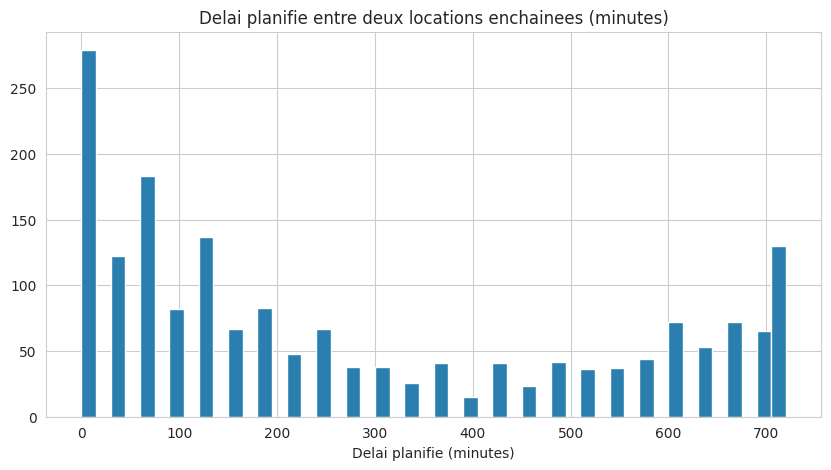

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(chained["time_delta_with_previous_rental_in_minutes"], bins=48, color="#2A7FAF")
ax.set_title("Delai planifie entre deux locations enchainees (minutes)")
ax.set_xlabel("Delai planifie (minutes)")
plt.show()


Seules **8.6% des locations** sont directement enchaînées à une location précédente sur la même voiture avec un délai de moins de 12h — c'est uniquement pour ces cas que le retard d'un conducteur peut affecter le suivant.

## 4. Quand le retard du premier conducteur affecte-t-il vraiment le suivant ?

In [10]:
# On recupere le retard au checkout de la location precedente pour chaque location enchainee
prev_delays = data[["rental_id", "delay_at_checkout_in_minutes"]].rename(
    columns={"rental_id": "previous_ended_rental_id", "delay_at_checkout_in_minutes": "previous_delay"}
)
chained = chained.merge(prev_delays, on="previous_ended_rental_id", how="left")
chained_known = chained.dropna(subset=["previous_delay"]).copy()

print(f"Locations enchainees avec un retard precedent connu : {len(chained_known)}")

# Le conducteur suivant est impacte si le retard du precedent depasse le delai qui avait ete planifie
chained_known["impact_minutes"] = chained_known["previous_delay"] - chained_known["time_delta_with_previous_rental_in_minutes"]
chained_known["actually_late_for_checkin"] = chained_known["impact_minutes"] > 0

n_impacted = chained_known["actually_late_for_checkin"].sum()
pct_impacted = chained_known["actually_late_for_checkin"].mean() * 100
print(f"Locations ou le conducteur suivant est reellement retarde : {n_impacted} ({pct_impacted:.1f}% des locations enchainees connues)")
print()
print("Retard subi par le conducteur suivant, quand il y en a un :")
print(chained_known.loc[chained_known["actually_late_for_checkin"], "impact_minutes"].describe())


Locations enchainees avec un retard precedent connu : 1729
Locations ou le conducteur suivant est reellement retarde : 218 (12.6% des locations enchainees connues)

Retard subi par le conducteur suivant, quand il y en a un :
count      218.000000
mean       177.568807
std        925.098783
min          1.000000
25%         11.000000
50%         26.500000
75%         80.250000
max      12548.000000
Name: impact_minutes, dtype: float64


**Résultat clé :** sur les locations enchaînées dont on connaît le retard précédent, **12.6%** entraînent un réel retard de checkin pour le conducteur suivant, avec un retard médian de **26.5 minutes**. Ce sont ces cas — environ **218 sur 21 310 locations (1.0%)** — que la feature de délai minimum vise à éliminer.

## 5. Simulation : quel seuil, pour quel périmètre ?

In [11]:
thresholds = [0, 15, 30, 45, 60, 90, 120, 180, 240, 360, 480, 720]
scopes = {
    "Toutes les voitures": chained_known,
    "Connect uniquement": chained_known[chained_known["checkin_type"] == "connect"],
}

total_rentals = len(data)
results = []
for scope_name, sub in scopes.items():
    total_problematic = sub["actually_late_for_checkin"].sum()
    for t in thresholds:
        affected = sub[sub["time_delta_with_previous_rental_in_minutes"] < t]
        results.append({
            "scope": scope_name,
            "threshold_min": t,
            "rentals_affected": len(affected),
            "pct_of_all_rentals": round(len(affected) / total_rentals * 100, 2),
            "problematic_cases_solved": int(affected["actually_late_for_checkin"].sum()),
            "pct_problematic_solved": round(affected["actually_late_for_checkin"].sum() / total_problematic * 100, 1) if total_problematic > 0 else 0,
        })

results_df = pd.DataFrame(results)
results_df


,scope,threshold_min,rentals_affected,pct_of_all_rentals,problematic_cases_solved,pct_problematic_solved
0,Toutes les voitures,0,0,0.00,0,0.0
1,Toutes les voitures,15,261,1.22,116,53.2
2,Toutes les voitures,30,261,1.22,116,53.2
3,Toutes les voitures,45,381,1.79,146,67.0
4,Toutes les voitures,60,381,1.79,146,67.0
5,Toutes les voitures,90,550,2.58,172,78.9
6,Toutes les voitures,120,630,2.96,180,82.6
7,Toutes les voitures,180,828,3.89,196,89.9
8,Toutes les voitures,240,951,4.46,202,92.7
9,Toutes les voitures,360,1112,5.22,208,95.4


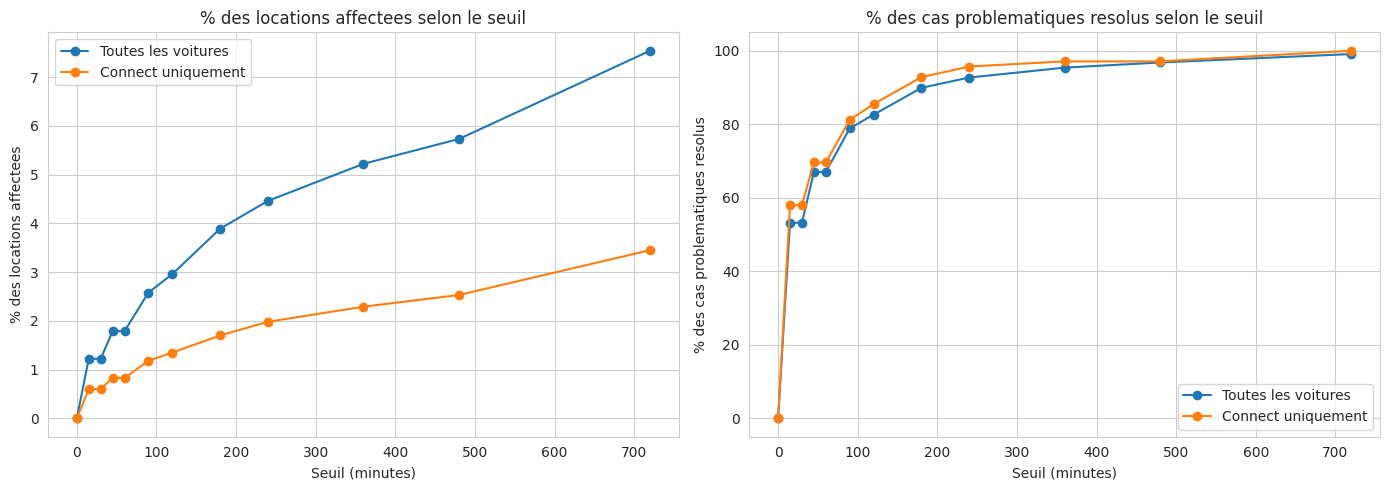

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scope_name in scopes:
    sub = results_df[results_df["scope"] == scope_name]
    axes[0].plot(sub["threshold_min"], sub["pct_of_all_rentals"], marker="o", label=scope_name)
    axes[1].plot(sub["threshold_min"], sub["pct_problematic_solved"], marker="o", label=scope_name)

axes[0].set_title("% des locations affectees selon le seuil")
axes[0].set_xlabel("Seuil (minutes)")
axes[0].set_ylabel("% des locations affectees")
axes[0].legend()

axes[1].set_title("% des cas problematiques resolus selon le seuil")
axes[1].set_xlabel("Seuil (minutes)")
axes[1].set_ylabel("% des cas problematiques resolus")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Réponses aux questions du brief

**Quelle part du revenu des propriétaires serait potentiellement affectée ?**
En l'absence de prix par location dans ce jeu de données, on approxime la part de revenu affectée par la part de locations affectées (en supposant que le fait d'être affecté par le seuil n'est pas corrélé au prix de la location). Cette part varie de **0.6% à 7.5%** selon le seuil et le périmètre choisis (voir tableau ci-dessus).

**Combien de locations seraient affectées selon le seuil et le périmètre ?**
Voir le tableau et les graphiques ci-dessus — de quelques centaines à ~1600 locations sur 21 310, selon le seuil.

**À quelle fréquence les conducteurs sont-ils en retard pour le check-in suivant, et quel impact ?**
12.6% des locations enchaînées causent un vrai retard pour le suivant, avec un retard médian de 26.5 minutes (mais une traîne pouvant aller jusqu'à plusieurs jours dans de rares cas extrêmes).

**Combien de cas problématiques seraient résolus selon le seuil ?**
De 53% (seuil à 15 min) à plus de 95% (seuil à 360+ min) des cas problématiques identifiés, selon le périmètre choisi.

## 7. Recommandation

Un seuil de **60 à 90 minutes**, appliqué **uniquement aux voitures Connect**, offre le meilleur compromis : il résout **70 à 80%** des cas problématiques identifiés tout en n'affectant qu'environ **1%** de l'ensemble des locations (et donc du revenu). Étendre la règle à toutes les voitures résout davantage de cas au même seuil, mais affecte une part plus importante du revenu. Au-delà de 240 minutes, les gains deviennent marginaux pour un coût croissant en locations bloquées.